In [4]:
import subprocess
subprocess.check_call(["pip", "install", "xgboost"])

0

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier



In [7]:
df = pd.read_csv('../data/cleaned_data/clustered_data.csv')
df.head()

,udi,type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,...,tool_wear_roll_mean_5,tool_wear_roll_std_5,tool_wear_delta,tool_wear_lag1,PC1,PC2,PC3,cluster_raw,health_regime,health_regime_enc
0,1,M,298.1,308.6,1551,42.8,0,0,0,0,...,0.000000,0.000000,0.0,107.951,-1.093847,-0.854210,-1.666416,1,Normal,0
1,2,L,298.2,308.7,1408,46.3,3,0,0,0,...,1.500000,2.121320,3.0,0.000,-1.602678,-0.215765,-1.618869,1,Normal,0
2,3,L,298.1,308.5,1498,49.4,5,0,0,0,...,2.666667,2.516611,2.0,3.000,-1.599406,-0.401641,-1.586248,1,Normal,0
3,4,L,298.2,308.6,1433,39.5,7,0,0,0,...,3.750000,2.986079,2.0,5.000,-1.230438,-0.664604,-1.555071,1,Normal,0
4,5,L,298.2,308.7,1408,40.0,9,0,0,0,...,4.800000,3.492850,2.0,7.000,-1.289814,-0.535153,-1.524319,1,Normal,0


In [6]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Null values: {df.isnull().sum().sum()}")


Shape: (10000, 46)
Columns: ['udi', 'type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'type_enc', 'temp_diff', 'power_W', 'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload', 'air_temperature_roll_mean_5', 'air_temperature_roll_std_5', 'air_temperature_delta', 'air_temperature_lag1', 'process_temperature_roll_mean_5', 'process_temperature_roll_std_5', 'process_temperature_delta', 'process_temperature_lag1', 'rotational_speed_roll_mean_5', 'rotational_speed_roll_std_5', 'rotational_speed_delta', 'rotational_speed_lag1', 'torque_roll_mean_5', 'torque_roll_std_5', 'torque_delta', 'torque_lag1', 'tool_wear_roll_mean_5', 'tool_wear_roll_std_5', 'tool_wear_delta', 'tool_wear_lag1', 'PC1', 'PC2', 'PC3', 'cluster_raw', 'health_regime', 'health_regime_enc']
Null values: 0


# Build Multi-Class Target


Class distribution:
failure_type
No Failure    9652
TWF             42
HDF            106
PWF             83
OSF             98
RNF             19
Name: count, dtype: int64


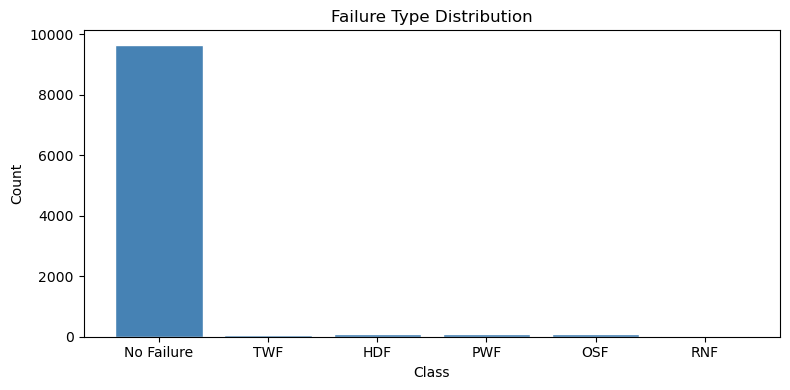

In [8]:
# Lowercase column names for safety
df.columns = df.columns.str.lower().str.strip()

# Build failure_type target (priority order as defined in spec)
df['failure_type'] = 0  # No failure
df.loc[df['twf'] == 1, 'failure_type'] = 1
df.loc[df['hdf'] == 1, 'failure_type'] = 2
df.loc[df['pwf'] == 1, 'failure_type'] = 3
df.loc[df['osf'] == 1, 'failure_type'] = 4
df.loc[df['rnf'] == 1, 'failure_type'] = 5

label_map = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF', 5: 'RNF'}

print('\nClass distribution:')
print(df['failure_type'].value_counts().sort_index().rename(label_map))

# Visualise
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['failure_type'].value_counts().sort_index()
ax.bar([label_map[i] for i in counts.index], counts.values, color='steelblue', edgecolor='white')
ax.set_title('Failure Type Distribution')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
 

# Feature Selection


In [9]:
FEATURES = [
    'air_temperature', 'process_temperature', 'rotational_speed',
    'torque', 'tool_wear', 'type_enc', 'temp_diff', 'power_w',
    'wear_rate', 'torque_speed_ratio', 'high_wear_flag',
    'thermal_overload', 'health_regime_enc', 'pc1', 'pc2'
]

# Keep only columns that exist in the dataframe
FEATURES = [f for f in FEATURES if f in df.columns]
print('Features used:', FEATURES)

X = df[FEATURES]
y = df['failure_type']

# SVM uses only PCA-reduced features as per spec
SVM_FEATURES = ['pc1', 'pc2']
X_svm = df[SVM_FEATURES]
 

Features used: ['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'type_enc', 'temp_diff', 'power_w', 'wear_rate', 'torque_speed_ratio', 'high_wear_flag', 'thermal_overload', 'health_regime_enc', 'pc1', 'pc2']


# Data Splitting

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_svm_train, X_svm_test = X_train[SVM_FEATURES], X_test[SVM_FEATURES]

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print('\nClass distribution in test set:')
print(y_test.value_counts().sort_index().rename(label_map))

Train size: 8000 | Test size: 2000

Class distribution in test set:
failure_type
No Failure    1930
TWF              8
HDF             21
PWF             17
OSF             20
RNF              4
Name: count, dtype: int64


# XGBOOST Model

In [32]:
# Compute sample weights to handle class imbalance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    num_class=6,
    objective='multi:softprob'
)

xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)

# Metrics
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
auc_xgb = roc_auc_score(y_test_bin, y_prob_xgb, multi_class='ovr', average='macro')

print(f'XGBoost  |  F1-Macro: {f1_xgb:.4f}  |  ROC-AUC (macro-OVR): {auc_xgb:.4f}')


XGBoost  |  F1-Macro: 0.6199  |  ROC-AUC (macro-OVR): 0.9152


## XGBoost confusion matrix

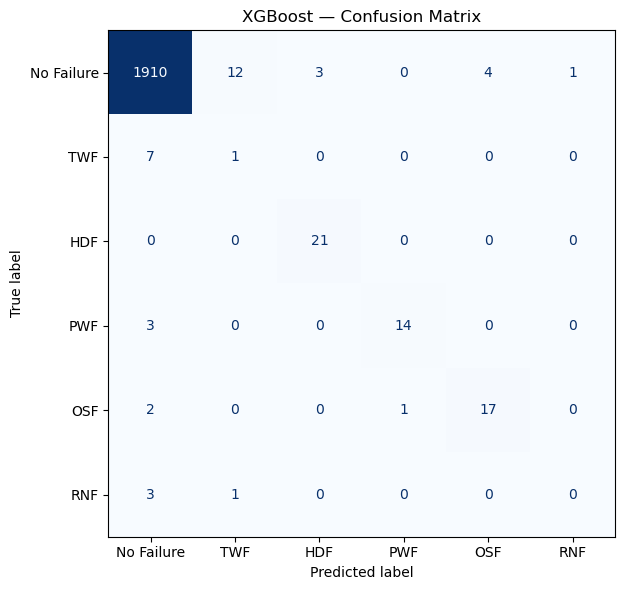

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=classes)
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=[label_map[i] for i in classes])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()

## XGBoost Feature Importance

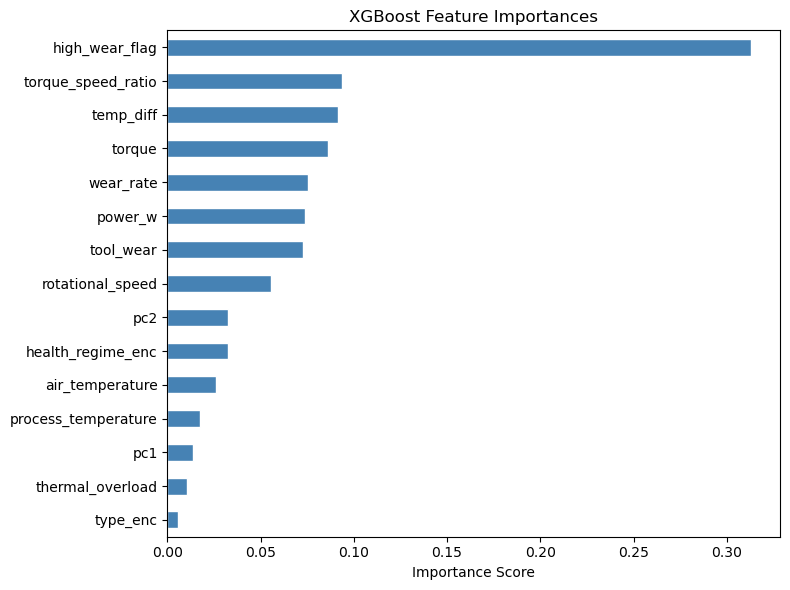

In [15]:
importances = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

# SVM MODEL

In [33]:
# GridSearchCV for C and gamma
param_grid = {
    'C': [1, 10],
    'gamma': ['scale', 0.1]
}

svm_base = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Subsample 30% of training data for tuning only (SVM is O(n^2), 10k samples is slow)
X_tune, _, y_tune, _ = train_test_split(
    X_svm_train, y_train, train_size=0.3, stratify=y_train, random_state=42
)

random_search = RandomizedSearchCV(
    svm_base, param_grid,
    n_iter=4,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Tune on subsample, then retrain best params on full training data
random_search.fit(X_tune, y_tune)
print(f'\nBest SVM params: {random_search.best_params_}')

best_params = random_search.best_params_
svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=42,
    **best_params
)
svm_model.fit(X_svm_train, y_train)  # retrain on full training data

y_pred_svm = svm_model.predict(X_svm_test)
y_prob_svm = svm_model.predict_proba(X_svm_test)

f1_svm = f1_score(y_test, y_pred_svm, average='macro')
auc_svm = roc_auc_score(y_test_bin, y_prob_svm, multi_class='ovr', average='macro')

print(f'SVM      |  F1-Macro: {f1_svm:.4f}  |  ROC-AUC (macro-OVR): {auc_svm:.4f}')


Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best SVM params: {'gamma': 'scale', 'C': 10}
SVM      |  F1-Macro: 0.2009  |  ROC-AUC (macro-OVR): 0.8175


## SVM Confusion Matrix

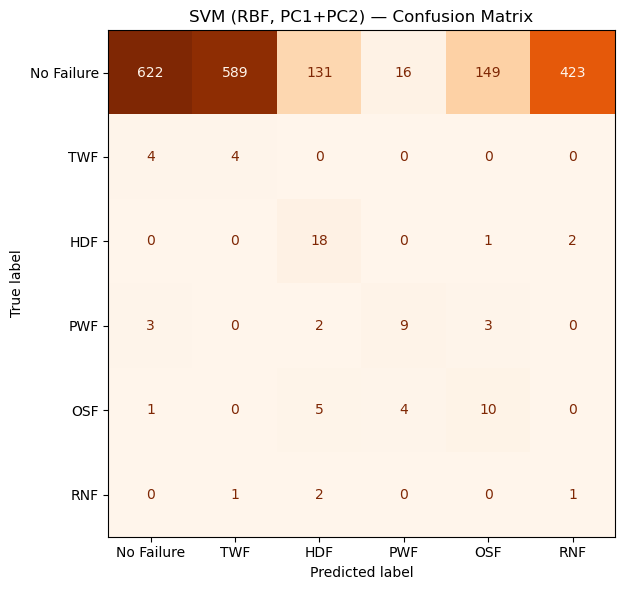

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=classes)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=[label_map[i] for i in classes])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('SVM (RBF, PC1+PC2) — Confusion Matrix')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

## SVM Decision Boundary

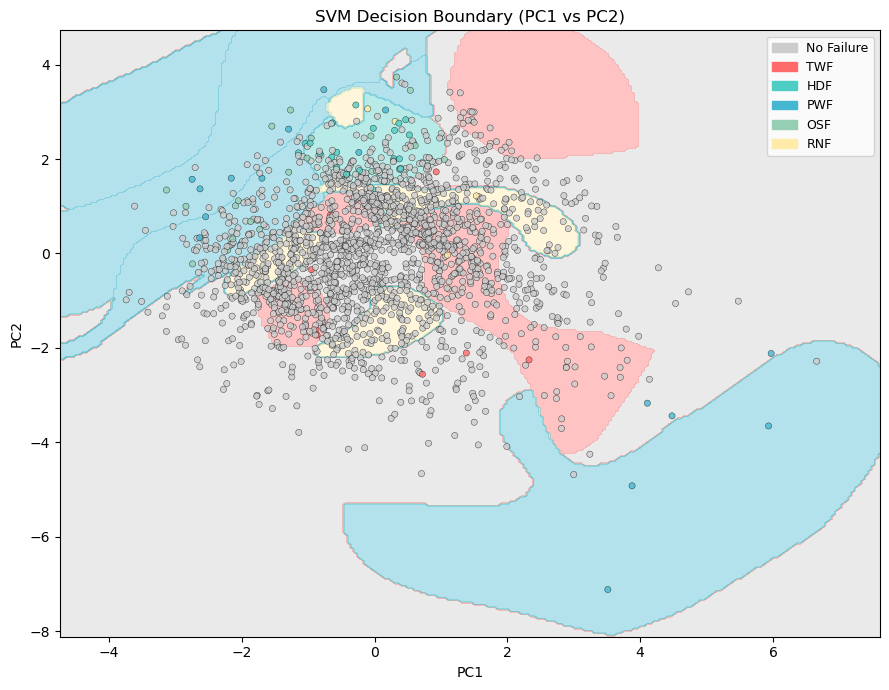

In [21]:
import matplotlib.patches as mpatches

h = 0.05
x_min, x_max = X_svm_test['pc1'].min() - 1, X_svm_test['pc1'].max() + 1
y_min, y_max = X_svm_test['pc2'].min() - 1, X_svm_test['pc2'].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = svm_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

colors = ['#cccccc', '#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4', '#ffeaa7']
cmap = plt.matplotlib.colors.ListedColormap(colors)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)

scatter_colors = [colors[c] for c in y_test]
ax.scatter(X_svm_test['pc1'], X_svm_test['pc2'], c=y_test,
           cmap=cmap, edgecolors='k', linewidths=0.3, s=20, alpha=0.8)

patches = [mpatches.Patch(color=colors[i], label=label_map[i]) for i in range(6)]
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('SVM Decision Boundary (PC1 vs PC2)')
plt.tight_layout()
plt.savefig('svm_decision_boundary.png', dpi=150)
plt.show()

# Classification Report

In [30]:
print('Classification Report — XGBoost:')
print(classification_report(y_test, y_pred_xgb, target_names=[label_map[i] for i in classes]))

Classification Report — XGBoost:
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1930
         TWF       0.07      0.12      0.09         8
         HDF       0.88      1.00      0.93        21
         PWF       0.93      0.82      0.88        17
         OSF       0.81      0.85      0.83        20
         RNF       0.00      0.00      0.00         4

    accuracy                           0.98      2000
   macro avg       0.61      0.63      0.62      2000
weighted avg       0.98      0.98      0.98      2000



In [31]:
print('Classification Report — SVM:')
print(classification_report(y_test, y_pred_svm, target_names=[label_map[i] for i in classes]))

Classification Report — SVM:
              precision    recall  f1-score   support

  No Failure       0.99      0.32      0.49      1930
         TWF       0.01      0.50      0.01         8
         HDF       0.11      0.86      0.20        21
         PWF       0.31      0.53      0.39        17
         OSF       0.06      0.50      0.11        20
         RNF       0.00      0.25      0.00         4

    accuracy                           0.33      2000
   macro avg       0.25      0.49      0.20      2000
weighted avg       0.96      0.33      0.48      2000



# Cross Validation

In [23]:
from sklearn.model_selection import cross_val_score

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost CV — on full feature set
xgb_cv = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, num_class=6, objective='multi:softprob'
)
xgb_cv_scores = cross_val_score(
    xgb_cv, X, y,
    cv=cv_outer, scoring='f1_macro', n_jobs=-1
)

# SVM CV — on PC1+PC2 only with best params found earlier
svm_cv = SVC(
    kernel='rbf', class_weight='balanced',
    probability=True, random_state=42,
    **best_params
)
svm_cv_scores = cross_val_score(
    svm_cv, X_svm, y,
    cv=cv_outer, scoring='f1_macro', n_jobs=-1
)

print('=== 5-Fold Cross-Validation F1-Macro Scores ===')
print(f'XGBoost : {xgb_cv_scores.round(4)}  →  Mean: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}')
print(f'SVM     : {svm_cv_scores.round(4)}  →  Mean: {svm_cv_scores.mean():.4f} ± {svm_cv_scores.std():.4f}')

=== 5-Fold Cross-Validation F1-Macro Scores ===
XGBoost : [0.597  0.6022 0.628  0.6106 0.599 ]  →  Mean: 0.6074 ± 0.0113
SVM     : [0.1994 0.1825 0.202  0.2028 0.1848]  →  Mean: 0.1943 ± 0.0088


# CV Score Distribution

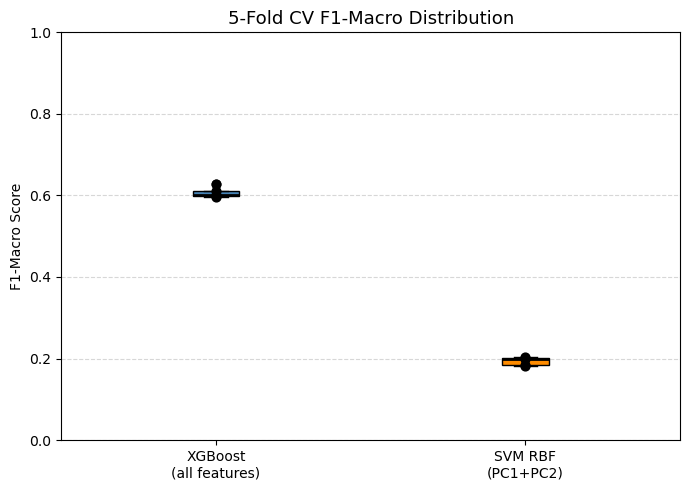

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [xgb_cv_scores, svm_cv_scores],
    labels=['XGBoost\n(all features)', 'SVM RBF\n(PC1+PC2)'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')

# Overlay individual fold scores
for i, scores in enumerate([xgb_cv_scores, svm_cv_scores], 1):
    ax.scatter([i]*len(scores), scores, color='black', zorder=5, s=40)

ax.set_title('5-Fold CV F1-Macro Distribution', fontsize=13)
ax.set_ylabel('F1-Macro Score')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('cv_boxplot.png', dpi=150)
plt.show()

# Model Comparison

In [25]:
results = pd.DataFrame({
    'Model':        ['XGBoost (all features)', 'SVM RBF (PC1+PC2)'],
    'F1-Macro':     [f1_xgb, f1_svm],
    'ROC-AUC':      [auc_xgb, auc_svm],
    'CV F1 Mean':   [xgb_cv_scores.mean(), svm_cv_scores.mean()],
    'CV F1 Std':    [xgb_cv_scores.std(), svm_cv_scores.std()]
})

print('\n=== Full Model Comparison ===')
print(results.to_string(index=False))


=== Full Model Comparison ===
                 Model  F1-Macro  ROC-AUC  CV F1 Mean  CV F1 Std
XGBoost (all features)  0.619905 0.915206    0.607374   0.011317
     SVM RBF (PC1+PC2)  0.200931 0.817498    0.194292   0.008803


### Comparison Bar Chart — Test Set F1 & ROC-AUC

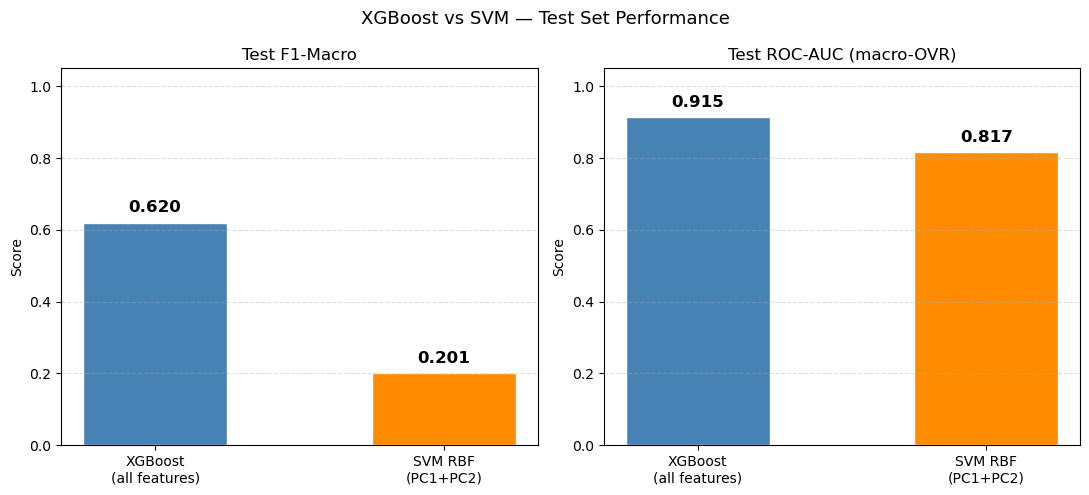

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
model_names = ['XGBoost\n(all features)', 'SVM RBF\n(PC1+PC2)']
colors = ['steelblue', 'darkorange']

for ax, (metric, vals) in zip(axes, [
    ('Test F1-Macro', [f1_xgb, f1_svm]),
    ('Test ROC-AUC (macro-OVR)', [auc_xgb, auc_svm])
]):
    bars = ax.bar(model_names, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel('Score')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.suptitle('XGBoost vs SVM — Test Set Performance', fontsize=13)
plt.tight_layout()
plt.savefig('test_comparison.png', dpi=150)
plt.show()

### Comparison Bar Chart — CV F1 with Error Bars

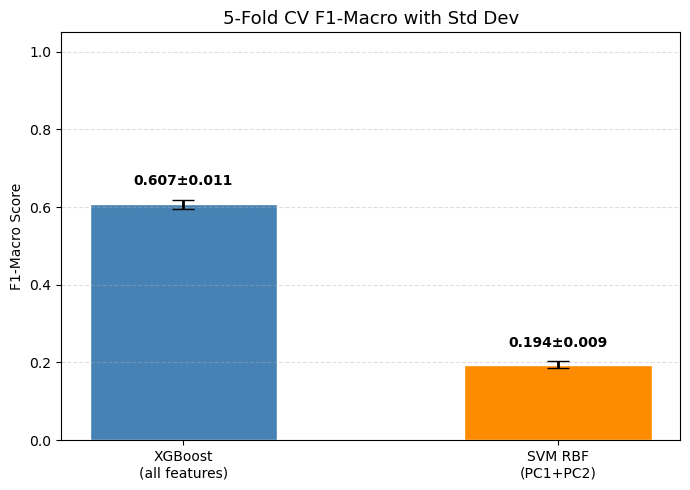

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
cv_means = [xgb_cv_scores.mean(), svm_cv_scores.mean()]
cv_stds  = [xgb_cv_scores.std(),  svm_cv_scores.std()]

bars = ax.bar(model_names, cv_means, yerr=cv_stds, color=colors,
              edgecolor='white', capsize=8, width=0.5,
              error_kw=dict(elinewidth=2, ecolor='black'))
ax.set_ylim(0, 1.05)
ax.set_title('5-Fold CV F1-Macro with Std Dev', fontsize=13)
ax.set_ylabel('F1-Macro Score')
ax.grid(axis='y', linestyle='--', alpha=0.4)
for bar, m, s in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2, m + s + 0.03,
            f'{m:.3f}±{s:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
plt.show()

### Side-by-Side Confusion Matrices

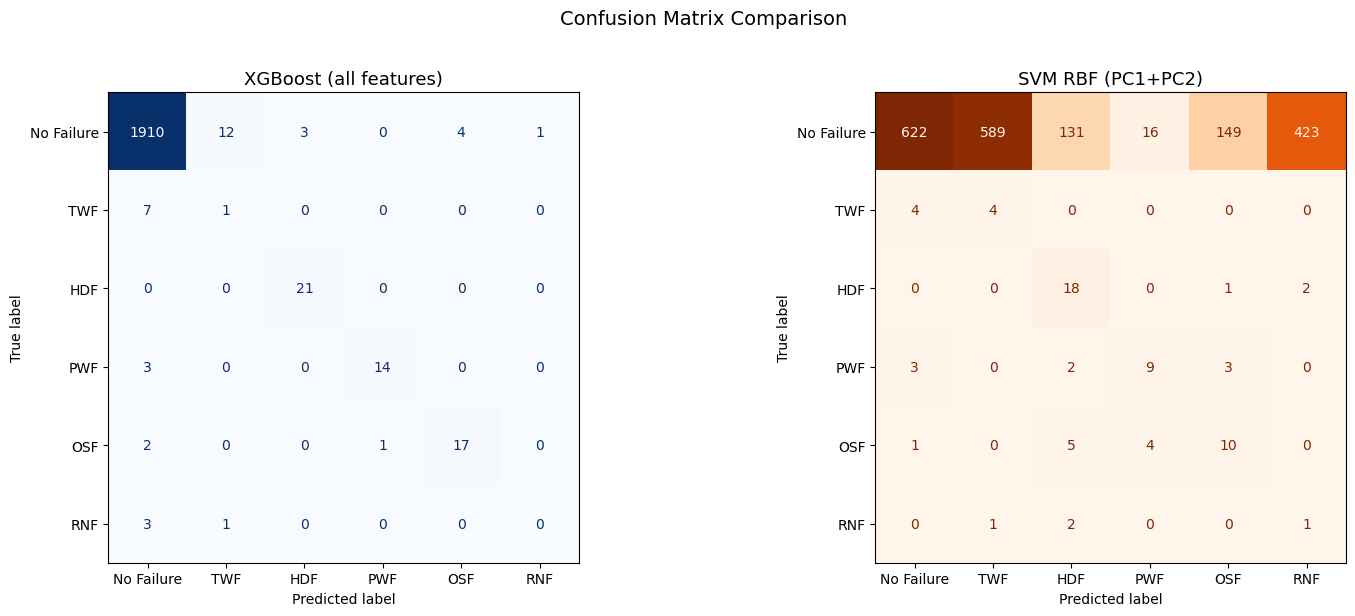

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
class_names = [label_map[i] for i in classes]

for ax, (cm, title, cmap) in zip(axes, [
    (confusion_matrix(y_test, y_pred_xgb, labels=classes), 'XGBoost (all features)', 'Blues'),
    (confusion_matrix(y_test, y_pred_svm, labels=classes), 'SVM RBF (PC1+PC2)',      'Oranges')
]):
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title, fontsize=13)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150)
plt.show()
 

### Per-Class F1 Score Comparison

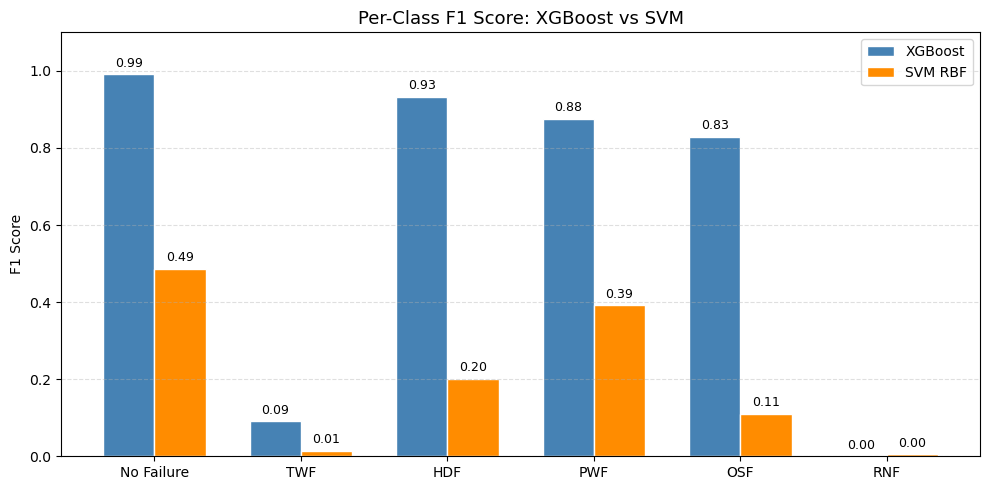

In [29]:
from sklearn.metrics import f1_score

f1_per_class_xgb = f1_score(y_test, y_pred_xgb, average=None, labels=classes)
f1_per_class_svm = f1_score(y_test, y_pred_svm, average=None, labels=classes)

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, f1_per_class_xgb, width, label='XGBoost', color='steelblue', edgecolor='white')
ax.bar(x + width/2, f1_per_class_svm, width, label='SVM RBF', color='darkorange', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([label_map[i] for i in classes])
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class F1 Score: XGBoost vs SVM', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

for i, (v1, v2) in enumerate(zip(f1_per_class_xgb, f1_per_class_svm)):
    ax.text(i - width/2, v1 + 0.02, f'{v1:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 0.02, f'{v2:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('perclass_f1_comparison.png', dpi=150)
plt.show()

# Final Graph — Predicted Failure Types (XGBoost vs Actual)

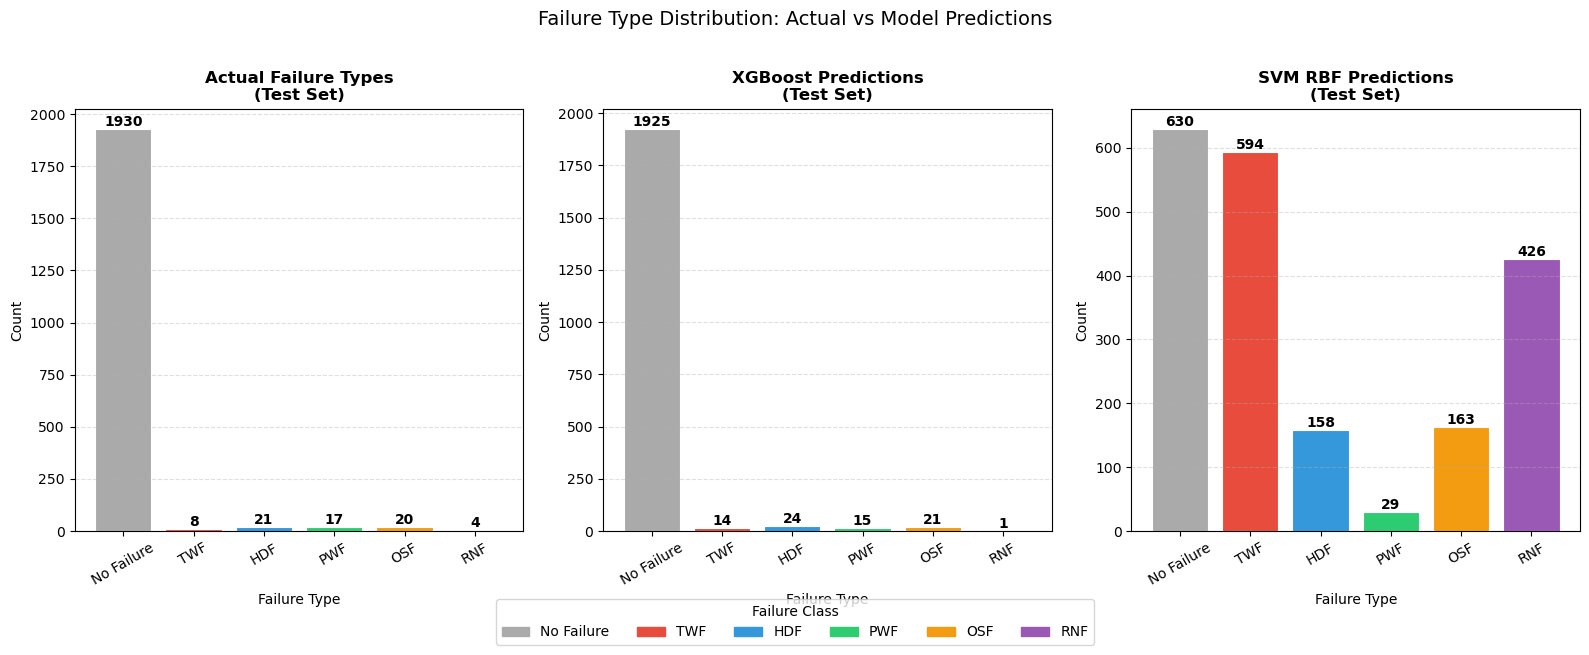


Actual counts:   {'No Failure': np.int64(1930), 'TWF': np.int64(8), 'HDF': np.int64(21), 'PWF': np.int64(17), 'OSF': np.int64(20), 'RNF': np.int64(4)}
XGBoost predicted: {'No Failure': np.int64(1925), 'TWF': np.int64(14), 'HDF': np.int64(24), 'PWF': np.int64(15), 'OSF': np.int64(21), 'RNF': np.int64(1)}
SVM predicted:     {'No Failure': np.int64(630), 'TWF': np.int64(594), 'HDF': np.int64(158), 'PWF': np.int64(29), 'OSF': np.int64(163), 'RNF': np.int64(426)}


In [34]:
import matplotlib.patches as mpatches

failure_colors = ['#aaaaaa', '#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
class_names    = [label_map[i] for i in range(6)]

# Build summary dataframes for actual vs predicted counts
actual_counts = pd.Series(y_test.values).value_counts().sort_index()
pred_xgb_counts = pd.Series(y_pred_xgb).value_counts().sort_index()
pred_svm_counts = pd.Series(y_pred_svm).value_counts().sort_index()

# Reindex to make sure all 6 classes present
idx = list(range(6))
actual_counts   = actual_counts.reindex(idx, fill_value=0)
pred_xgb_counts = pred_xgb_counts.reindex(idx, fill_value=0)
pred_svm_counts = pred_svm_counts.reindex(idx, fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

for ax, (counts, title) in zip(axes, [
    (actual_counts,   'Actual Failure Types\n(Test Set)'),
    (pred_xgb_counts, 'XGBoost Predictions\n(Test Set)'),
    (pred_svm_counts, 'SVM RBF Predictions\n(Test Set)')
]):
    bars = ax.bar(
        class_names, counts.values,
        color=failure_colors, edgecolor='white', linewidth=0.8
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Failure Type')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    for bar, v in zip(bars, counts.values):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                    str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

patches = [mpatches.Patch(color=failure_colors[i], label=class_names[i]) for i in range(6)]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=10,
           bbox_to_anchor=(0.5, -0.05), title='Failure Class')

plt.suptitle('Failure Type Distribution: Actual vs Model Predictions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('failure_type_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nActual counts:  ', dict(zip(class_names, actual_counts.values)))
print('XGBoost predicted:', dict(zip(class_names, pred_xgb_counts.values)))
print('SVM predicted:    ', dict(zip(class_names, pred_svm_counts.values)))

# Saving Models

In [35]:
import joblib
import os

os.makedirs("outputs", exist_ok=True)

joblib.dump(xgb_model, "outputs/xgb_classifier.pkl")
joblib.dump(svm_model, "outputs/svm_pipeline.pkl")

print("Saved: xgb_classifier.pkl")
print("Saved: svm_pipeline.pkl")

Saved: xgb_classifier.pkl
Saved: svm_pipeline.pkl


# Final result

In [36]:
from sklearn.metrics import accuracy_score

xgb_acc = accuracy_score(y_test, y_pred_xgb)
svm_acc = accuracy_score(y_test, y_pred_svm)

print("\n" + "=" * 60)
print("  FINAL RESULTS SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    "Model"      : ["XGBoost", "SVM (RBF)"],
    "Accuracy"   : [round(xgb_acc,              4), round(svm_acc,              4)],
    "F1-macro"   : [round(f1_xgb,               4), round(f1_svm,               4)],
    "AUC-macro"  : [round(auc_xgb,              4), round(auc_svm,              4)],
    "CV F1 mean" : [round(xgb_cv_scores.mean(), 4), round(svm_cv_scores.mean(), 4)],
    "CV F1 std"  : [round(xgb_cv_scores.std(),  4), round(svm_cv_scores.std(),  4)],
})
print(summary.to_string(index=False))

winner = "XGBoost" if f1_xgb >= f1_svm else "SVM (RBF)"
print(f"\n  Best model by F1-macro: {winner}")
print("=" * 60)


  FINAL RESULTS SUMMARY
    Model  Accuracy  F1-macro  AUC-macro  CV F1 mean  CV F1 std
  XGBoost    0.9815    0.6199     0.9152      0.6074     0.0113
SVM (RBF)    0.3320    0.2009     0.8175      0.1943     0.0088

  Best model by F1-macro: XGBoost
